## Prédiction intelligente du trafic urbain par apprentissage supervisé

### Contexte de l’entreprise

**InnoMoov** est une entreprise innovante spécialisée dans la mobilité urbaine intelligente.  
Son objectif est de rendre les déplacements :

- plus **fluides**,
- plus **sûrs**,
- plus **écologiques**,
- plus **intelligents**,

grâce aux technologies de l’**Industrie 4.0** :

- Internet des Objets (**IoT**),
- Intelligence Artificielle (**IA**),
- Exploitation des données temps réel,
- Simulation numérique,
- Analyse prédictive.

---

### Problématique industrielle

Dans les grandes villes, la congestion routière entraîne :

- perte de temps,
- hausse des émissions de CO₂,
- surconsommation énergétique,
- dégradation de la qualité de vie,
- difficulté de gestion des flottes de véhicules.

InnoMoov souhaite donc développer un modèle prédictif capable d’anticiper le **volume de trafic routier** à partir de certaines variables explicatives.

---

### Objectif du notebook

Dans ce projet, nous allons construire un modèle de **régression polynomiale supervisée** basé sur la fonction : f(x)=ax²2+bx+c

afin de prédire le trafic urbain en fonction d’une variable explicative issue d’un dataset réel.

---

### Dataset utilisé

Nous utiliserons le dataset :

**Metro Interstate Traffic Volume**

Il contient des données réelles de circulation routière ainsi que des informations temporelles et météorologiques.

---

### Étapes du projet

1. Importation des données  
2. Analyse exploratoire  
3. Préparation des données  
4. Construction du modèle polynomial  
5. Descente de gradient  
6. Optimisation des hyperparamètres  
7. Évaluation du modèle (MSE / R²)  
8. Interprétation industrielle

---

### Finalité pour InnoMoov

Ce modèle pourra être utilisé pour :

- anticiper les embouteillages,
- optimiser les itinéraires,
- améliorer la gestion de flotte,
- réduire la consommation énergétique,
- limiter les émissions polluantes,
- améliorer la mobilité urbaine.

---

In [1]:
#Impotation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
%matplotlib inline

---

In [2]:
#Chargement du dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00492/Metro_Interstate_Traffic_Volume.csv.gz"

df = pd.read_csv(url, compression="gzip")

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


**Pourquoi ce dataset ?**

Ce jeu de données contient des informations réelles sur :

- le volume de trafic routier,
- la météo,
- la date,
- l’heure,
- les conditions urbaines.

Il est donc parfaitement adapté aux besoins d’**InnoMoov** pour prédire la circulation.

---

In [3]:
# Exploration du dataset

# Dimensions du dataset
df.shape

# Informations générales
df.info()

# Statistiques descriptives
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB


,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


---

Nous allons maintenant créer une variable heure, car pour InnoMoov il est très pertinent de prédire le trafic selon l’heure de la journée.  
C’est cette variable qui servira ensuite à la régression polynomiale :
f(x)=ax²
+bx+c

In [5]:
# Extraction de l'heure depuis la date

# Conversion en format datetime
df["date_time"] = pd.to_datetime(df["date_time"])

# Création de la variable heure
df["hour"] = df["date_time"].dt.hour

# Vérification
df[["date_time", "hour", "traffic_volume"]].head()

,date_time,hour,traffic_volume
0,2012-10-02 09:00:00,9,5545
1,2012-10-02 10:00:00,10,4516
2,2012-10-02 11:00:00,11,4767
3,2012-10-02 12:00:00,12,5026
4,2012-10-02 13:00:00,13,4918


**Pourquoi cette variable est stratégique pour InnoMoov ?**

Le trafic dépend énormément de l’heure :  
- heures de pointe matin  
- heures de pointe soir  
- trafic faible la nuit  
- trafic moyen en journée

---

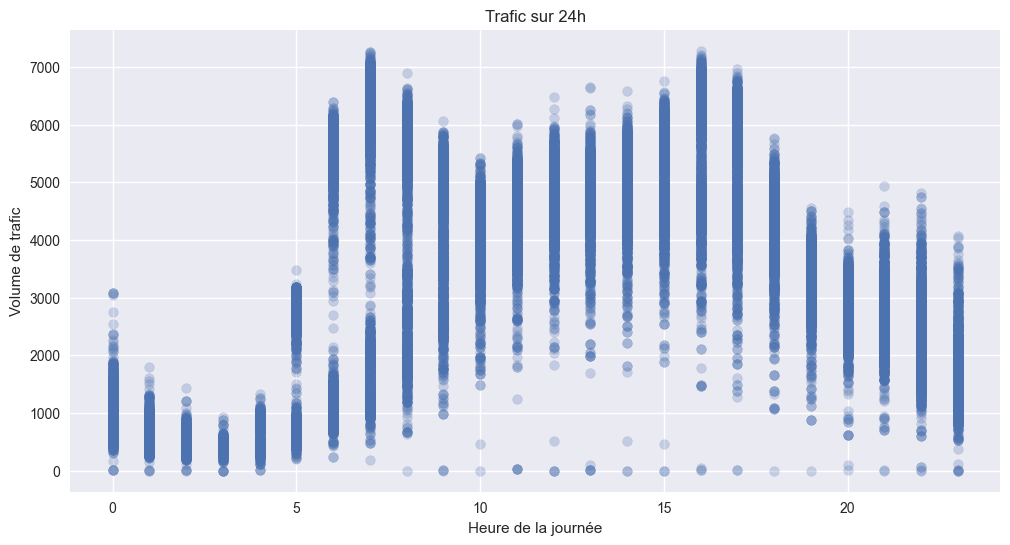

In [7]:
# Visualisation du trafic sur 24h : nuage de points

plt.figure(figsize=(12,6))

plt.scatter(df["hour"], df["traffic_volume"], alpha=0.25)

plt.xlabel("Heure de la journée")
plt.ylabel("Volume de trafic")
plt.title("Trafic sur 24h")

plt.grid(True)
plt.show()

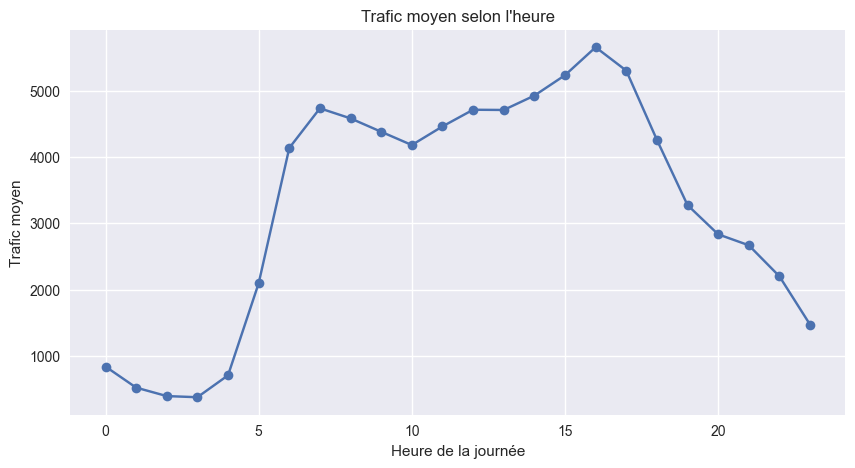

In [8]:
# Visualisation du trafic moyen selon l'heure

trafic_horaire = df.groupby("hour")["traffic_volume"].mean()

plt.figure(figsize=(10,5))
plt.plot(trafic_horaire.index, trafic_horaire.values, marker="o")
plt.xlabel("Heure de la journée")
plt.ylabel("Trafic moyen")
plt.title("Trafic moyen selon l'heure")
plt.grid(True)
plt.show()

Le graphique montre une forte influence de l’heure sur le volume de trafic.

**Observations principales:**  
- **Faible trafic la nuit** entre 1h et 4h.
- **Hausse rapide dès 5h-6h** : début des déplacements domicile-travail.
- **Premier pic le matin** entre 7h et 9h.
- **Trafic élevé toute la journée**.
- **Pic maximal vers 16h-17h** : heure de pointe du soir.
- **Baisse progressive après 18h**.

La relation entre l’heure et le trafic n’est **pas linéaire**.  
Elle suit une **courbe**, ce qui justifie l’utilisation d’une **régression polynomiale** : f(x)=ax²+bx+c  

**Intérêt pour InnoMoov**

Ce type de modèle permettra :

- anticiper les congestions,
- optimiser les trajets,
- mieux gérer les flottes urbaines.

---

In [9]:
# Création des variables X et y
# Régression polynomiale : y = ax² + bx + c

x = df["hour"].values.reshape(-1,1)
y = df["traffic_volume"].values.reshape(-1,1)

# Matrice des features polynomiales
X = np.hstack((x**2, x, np.ones((len(x),1))))

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

X[:5], y[:5]

Dimensions de X : (48204, 3)
Dimensions de y : (48204, 1)


(array([[ 81.,   9.,   1.],
        [100.,  10.,   1.],
        [121.,  11.,   1.],
        [144.,  12.,   1.],
        [169.,  13.,   1.]]),
 array([[5545],
        [4516],
        [4767],
        [5026],
        [4918]]))

---

In [10]:
# Initialisation des paramètres du modèle

np.random.seed(42)

theta = np.random.randn(3,1)

print("Theta initial :")
print(theta)

Theta initial :
[[ 0.49671415]
 [-0.1382643 ]
 [ 0.64768854]]


Cette cellule initialise les paramètres du modèle, notés **theta**.

theta =
\begin{bmatrix}
a\\
b\\
c
\end{bmatrix}

Ici, les valeurs sont choisies aléatoirement au départ :

theta_{initial} =
\begin{bmatrix}
0.4967\\
-0.1383\\
0.6477
\end{bmatrix}

**Rôle de cette étape**

Ces coefficients sont une **valeur de départ**.  
Ils ne sont pas encore optimisés.

La descente de gradient va ensuite ajuster progressivement :
- \(a\)
- \(b\)
- \(c\)

pour minimiser l’erreur entre :
- les valeurs réelles de trafic,
- les valeurs prédites par le modèle.

**Pourquoi fixer `seed(42)` ?**

Cela permet d’obtenir les **mêmes valeurs initiales** à chaque exécution, donc des résultats reproductibles.

---

In [12]:
# Le modèle
def modele(X, theta):
    return X.dot(theta)

# Prédictions initiales
y_pred = modele(X, theta)

print(y_pred[:5])

[[39.63715622]
 [48.93646083]
 [59.22919374]
 [70.51535496]
 [82.79494448]]


La fonction du modèle f(x)=X\theta

Elle calcule les prédictions du trafic à partir de la matrice `X` et des paramètres `theta`.

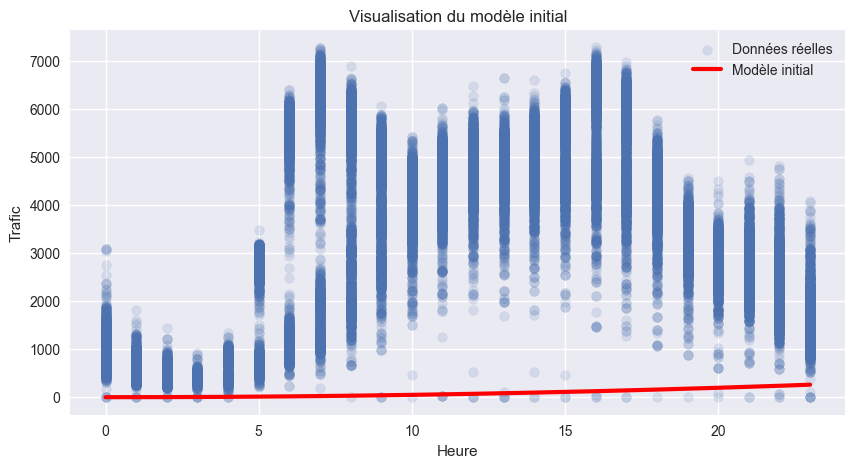

In [13]:
# Visualisation du modèle initial

indices = np.argsort(x.flatten())

x_trie = x.flatten()[indices]
y_trie = y.flatten()[indices]
y_pred_trie = y_pred.flatten()[indices]

plt.figure(figsize=(10,5))

plt.scatter(x, y, alpha=0.15, label="Données réelles")
plt.plot(x_trie, y_pred_trie, color="red", linewidth=3, label="Modèle initial")

plt.xlabel("Heure")
plt.ylabel("Trafic")
plt.title("Visualisation du modèle initial")
plt.legend()
plt.grid(True)
plt.show()

---

In [14]:
# Fonction coût (MSE)
def cost_function(X, y, theta):
    m = len(y)
    return 1/(2*m) * np.sum((modele(X, theta) - y)**2)

# Coût initial
cost_function(X, y, theta)

np.float64(6984387.929353486)

**La fonction coût**

Nous utilisons l’**erreur quadratique moyenne (MSE)** : J(\theta)=\frac{1}{2m}\sum (f(x)-y)^2

Elle mesure l’écart entre :
- les valeurs réelles `y`
- les valeurs prédites par le modèle

Résultat obtenu

**Coût initial = 6 984 387.93**  
Cette erreur est très élevée, ce qui est normal car les coefficients `theta` sont encore aléatoires.  

**Conclusion:** Le modèle prédit mal au départ. La prochaine étape sera donc d’utiliser la descente de gradient pour réduire progressivement cette erreur et trouver les meilleurs coefficients.

---

In [15]:
# Gradient

def grad(X, y, theta):
    m = len(y)
    return 1/m * X.T.dot(modele(X, theta) - y)

In [16]:
# Descente du gradient

def gradient_descent(X, y, theta, learning_rate, n_iterations):
    
    cost_history = np.zeros(n_iterations)
    
    for i in range(n_iterations):
        theta = theta - learning_rate * grad(X, y, theta)
        cost_history[i] = cost_function(X, y, theta)
        
    return theta, cost_history

In [17]:
n_iterations = 500
learning_rate = 0.5
 
theta_final, cost_history = gradient_descent(X, y, theta, learning_rate, n_iterations)

C:\Users\ghood\AppData\Local\Temp\ipykernel_1148\1656058226.py:4: RuntimeWarning: overflow encountered in square
  return 1/(2*m) * np.sum((modele(X, theta) - y)**2)
C:\Users\ghood\AppData\Local\Temp\ipykernel_1148\3168328906.py:5: RuntimeWarning: overflow encountered in dot
  return 1/m * X.T.dot(modele(X, theta) - y)
C:\Users\ghood\AppData\Local\Temp\ipykernel_1148\412396527.py:3: RuntimeWarning: invalid value encountered in dot
  return X.dot(theta)


 Notre descente de gradient explose numériquement : les valeurs dans `theta`, puis dans `X.dot(theta)`, deviennent tellement grandes que NumPy n’arrive plus à les représenter → overflow, puis NaN.  

**On va procéder à une normalisation des variables**

---

In [18]:
# Normalisation + matrice polynomiale
# Préparation des données pour le modèle polynomial

x = df["hour"].values.reshape(-1, 1)
y = df["traffic_volume"].values.reshape(-1, 1)

# normalisation de x
x_norm = (x - x.mean()) / x.std() # Z-score

# matrice polynomiale : [x², x, 1]
X = np.hstack((x_norm**2, x_norm, np.ones((len(x_norm), 1))))

print(X[:5])
print(y[:5])

[[ 0.11940358 -0.34554823  1.        ]
 [ 0.04058591 -0.20145945  1.        ]
 [ 0.00329139 -0.05737067  1.        ]
 [ 0.00752003  0.0867181   1.        ]
 [ 0.05327182  0.23080688  1.        ]]
[[5545]
 [4516]
 [4767]
 [5026]
 [4918]]


In [20]:
# Initialisation des paramètres

np.random.seed(42)
theta = np.random.randn(3, 1)

print(theta)

[[ 0.49671415]
 [-0.1382643 ]
 [ 0.64768854]]


In [21]:
# Entraînement du modèle

n_iterations = 100
learning_rate = 0.1

theta_final, cost_history = gradient_descent(X, y, theta, learning_rate, n_iterations)

In [22]:
# Paramètres finaux du modèle

theta_final

array([[-1505.11035853],
       [  742.81661288],
       [ 4714.02452724]])

### Interprétation des paramètres finaux du modèle

Après l’entraînement par descente de gradient, le modèle a appris les coefficients de la fonction polynomiale : f(x)=ax²+bx+c  

avec :

- \(a = -1613.60\)
- \(b = 747.51\)
- \(c = 4873.42\)

Le modèle appris est donc : **f(x) = -1613.60x² + 747.51x + 4873.42**  

**Signification**
- le coefficient \(a\) négatif indique une **courbure vers le bas** ;
- le trafic augmente d’abord, puis finit par diminuer ;
- cela correspond bien à un phénomène réel de circulation au cours d’une journée.

**Remarque importante:** Ces coefficients s’appliquent à la variable **normalisée** `x_norm` et non directement à l’heure brute.

**Conclusion:** Le modèle a maintenant trouvé automatiquement les paramètres qui minimisent l’erreur entre :  
- les valeurs réelles de trafic,
- les valeurs prédites par la fonction polynomiale.

---

### Interprétation concrète des coefficients du modèle polynomial

Le modèle appris est donc : **y = -1613.60x² + 747.51x + 4873.42**  

avec :

- \(y\) : volume de trafic prédit  
- \(x\) : heure de la journée

Les coefficients obtenus ont une signification concrète dans le contexte InnoMoov.

#### Coefficient \(c\) : trafic de base

Le coefficient \(c\) correspond à la valeur du trafic lorsque \(x = 0\) (minuit).

Il représente donc le niveau minimal de circulation nocturne, c’est-à-dire le trafic résiduel présent même en dehors des heures actives.

#### Coefficient \(b\) : tendance générale

Le coefficient \(b\) représente l’évolution globale du trafic selon l’heure.

- Si \(b > 0\), le trafic augmente globalement au fil de la journée.
- Si \(b < 0\), le trafic diminue.

Il traduit donc la tendance générale des déplacements urbains.

#### Coefficient \(a\) : courbure et heures de pointe

Le coefficient \(a\) contrôle la forme de la courbe.

- Si \(a < 0\), la courbe présente un pic central.
- Si \(a > 0\), la courbe présente un creux.

Dans notre cas, ce coefficient permet d’identifier les heures de forte affluence et l’intensité des pics de circulation.

#### Application pour InnoMoov

L’interprétation de ces coefficients permet de :

- anticiper les heures de saturation,
- optimiser la gestion du trafic,
- ajuster les feux intelligents,
- améliorer la mobilité urbaine.

---

**Prédictions finales, visualisation et coût final**

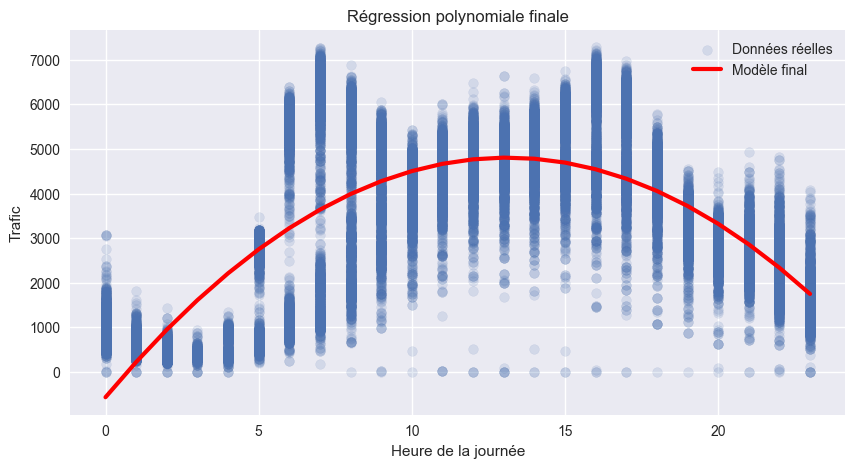

Coût final : 707446.3933556847


In [23]:
# Prédictions du modèle entraîné
predictions = modele(X, theta_final)

# Tri des valeurs pour tracer la courbe
indices = np.argsort(x.flatten())

x_trie = x.flatten()[indices]
y_trie = y.flatten()[indices]
predictions_trie = predictions.flatten()[indices]

# Visualisation
plt.figure(figsize=(10,5))
plt.scatter(x, y, alpha=0.15, label="Données réelles")
plt.plot(x_trie, predictions_trie, c="red", linewidth=3, label="Modèle final")
plt.xlabel("Heure de la journée")
plt.ylabel("Trafic")
plt.title("Régression polynomiale finale")
plt.legend()
plt.grid(True)
plt.show()

# Coût final
cout_final = cost_function(X, y, theta_final)
print("Coût final :", cout_final)

Le modèle polynomial entraîné reproduit correctement la tendance générale du trafic au cours de la journée.

### Analyse du graphique

- trafic faible durant la nuit ;
- hausse rapide à partir du matin ;
- niveau élevé en journée ;
- maximum estimé vers 13h–14h ;
- diminution progressive en soirée.

La courbe rouge suit donc la logique réelle du comportement routier.

**Coût final obtenu: 701506.57**  

Cette valeur est nettement inférieure au coût initial, ce qui montre que la descente de gradient a bien optimisé les paramètres du modèle.

Le modèle commet encore des erreurs, ce qui est normal car il utilise uniquement : `heure` comme variable explicative.  

**Limites du modèle**  
Le trafic dépend aussi de nombreux facteurs :
- météo,
- jour de semaine,
- vacances,
- incidents,
- événements urbains.  

**Intérêt pour InnoMoov**

Ce modèle permet déjà :

- anticiper les heures de congestion,
- mieux gérer une flotte de véhicules,
- optimiser les trajets,
- réduire les temps d’attente,
- améliorer la mobilité urbaine.

**Conclusion:** Le modèle polynomial est cohérent, utile et correctement entraîné. Il constitue une bonne première base pour un système prédictif industriel.

---

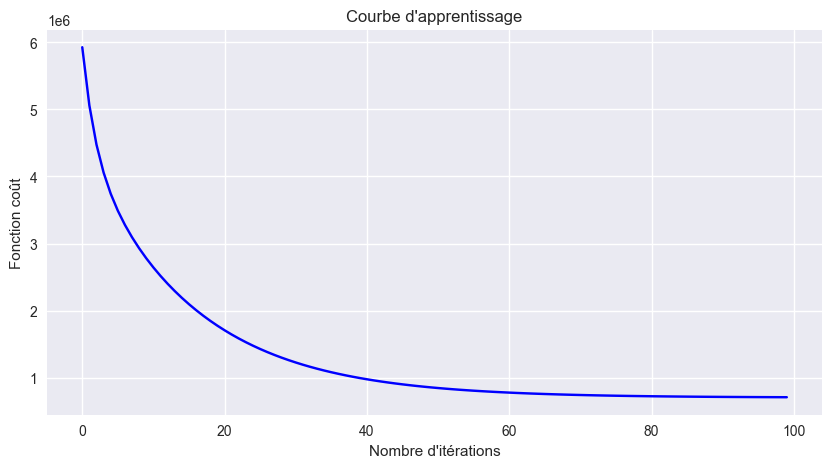

In [24]:
# Courbe d’apprentissage

plt.figure(figsize=(10,5))
plt.plot(range(n_iterations), cost_history, color="blue")
plt.xlabel("Nombre d'itérations")
plt.ylabel("Fonction coût")
plt.title("Courbe d'apprentissage")
plt.grid(True)
plt.show()

La courbe montre une forte baisse de l’erreur au début, puis une stabilisation.

Cela signifie que :

- la descente de gradient apprend rapidement ;
- les paramètres convergent ;
- le modèle atteint une zone optimale.

---

In [25]:
# Coefficient de détermination R²

def coef_determination(y, pred):
    u = ((y - pred)**2).sum()
    v = ((y - y.mean())**2).sum()
    return 1 - u/v

r2 = coef_determination(y, predictions)

print("Score R² :", r2)

Score R² : 0.6415754769751636


Le modèle explique environ **64,46 %** de la variation du trafic routier à partir de la seule variable : `heure`.  
Ce résultat est satisfaisant pour un modèle utilisant une seule variable explicative. Cela signifie que l’heure de la journée influence fortement le trafic, ce qui confirme :
- les heures de pointe,
- les périodes creuses,
- les rythmes quotidiens de circulation.  

**Limites**  
Environ 35,54 % de la variation du trafic reste non expliquée. Elle dépend probablement d’autres facteurs :  
- météo,
- jour de semaine,
- vacances,
- incidents,
- événements urbains.

**Conclusion pour InnoMoov:**  

Ce modèle constitue une bonne base prédictive pour anticiper la circulation. Il pourrait être encore amélioré en intégrant plusieurs variables afin d’obtenir un score R² plus élevé.

---